<a href="https://colab.research.google.com/github/Lyanan85/In-GameSeries/blob/venv/projeto_redwine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

In [ ]:
df = pd.read_csv("winequality-red.csv")
df_clean = df.copy().drop_duplicates()

In [ ]:

print(f"Todas as notas unicas na coluna qualidade: {df_clean['quality'].unique()}")
df_clean["quality"].value_counts().sort_index(ascending=False)


Todas as notas unicas na coluna qualidade: [5 6 7 4 8 3]


,count
quality,
8,17
7,167
6,535
5,577
4,53
3,10


In [ ]:
dfsugar_alcohol = df_clean.groupby("quality")[["residual sugar", "alcohol"]].mean().reset_index()

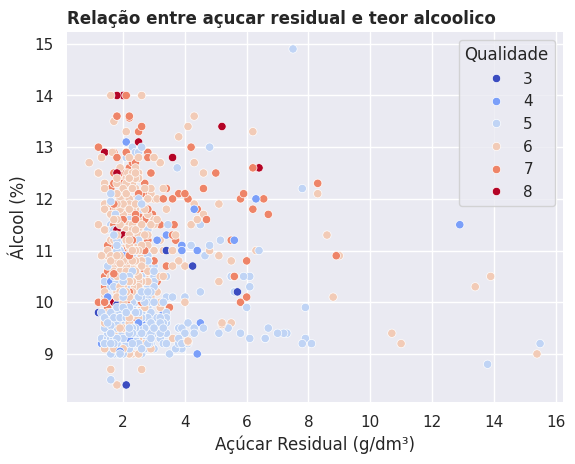

In [ ]:
sns.set(style="darkgrid")
sns.scatterplot(data=df_clean, x="residual sugar", y="alcohol", hue="quality", palette="coolwarm")
sns.despine(left=True, bottom=True)
plt.title("Relação entre açucar residual e teor alcoolico", fontsize=12, loc="Left", fontweight="bold")
plt.xlabel('Açúcar Residual (g/dm³)')
plt.ylabel('Álcool (%)')
plt.legend(title='Qualidade')
plt.show()


In [ ]:
fig = px.scatter(
    df_clean,
    x="residual sugar",
    y="alcohol",
    color="quality",
    size="quality",
    hover_name="quality",
    title="Relação entre Açucar Residual e Teor Alcoólico",
    template="plotly_dark",
    labels={
        "residual sugar": "Açúcar Residual (g/dm³)",
        "alcohol": "Álcool(%)",
        "quality": "Qualidade"
    }
)
fig.show()


In [ ]:

def identify_outliers(df, col, fator=1.5):
    """Identifica os índices dos outliers em uma coluna usando o método IQR."""
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - fator * iqr
    limite_superior = q3 + fator * iqr
    return df[(df[col] < limite_inferior) | (df[col] > limite_superior)].index

In [ ]:
# Remover outliers para as colunas relevantes
df_sem_outliers_final = df_clean.copy()
cols_to_clean = ["residual sugar", "alcohol", "pH"]
for col in cols_to_clean:
    if col in df_sem_outliers_final.columns:
        outliers_indices = identify_outliers(df_sem_outliers_final, col)
        df_sem_outliers_final = df_sem_outliers_final.drop(outliers_indices)

print("Antes da remoção de outliers:", df_clean.shape[0])
print("Depois da remoção de outliers:", df_sem_outliers_final.shape[0])
print("Total de outliers removidos:", df_clean.shape[0] - df_sem_outliers_final.shape[0])

Antes da remoção de outliers: 1359
Depois da remoção de outliers: 1196
Total de outliers removidos: 163


In [ ]:

def categorize_wine(quality):
    if quality <= 5:
        return "Baixa-Qualidade"
    elif quality >= 7:
        return "Alta-Qualidade"
    else:
        return "Média-Qualidade"

df_sem_outliers_final["Categoria"] = df_sem_outliers_final["quality"].apply(categorize_wine)

In [ ]:

df_categorias = df_sem_outliers_final.groupby("Categoria")[["residual sugar", "pH", "alcohol", "quality"]].mean().reset_index()

In [ ]:
outliers_sugar = identify_outliers(df_sem_outliers_final, "residual sugar")
outliers_alcohol = identify_outliers(df_sem_outliers_final, "alcohol")
outliers_ph = identify_outliers(df_sem_outliers_final, "pH")

In [ ]:
all_outliers = set(outliers_sugar) | set(outliers_alcohol) | set(outliers_ph)

In [ ]:
df_sem_outliers_final = df_sem_outliers_final.drop(all_outliers)

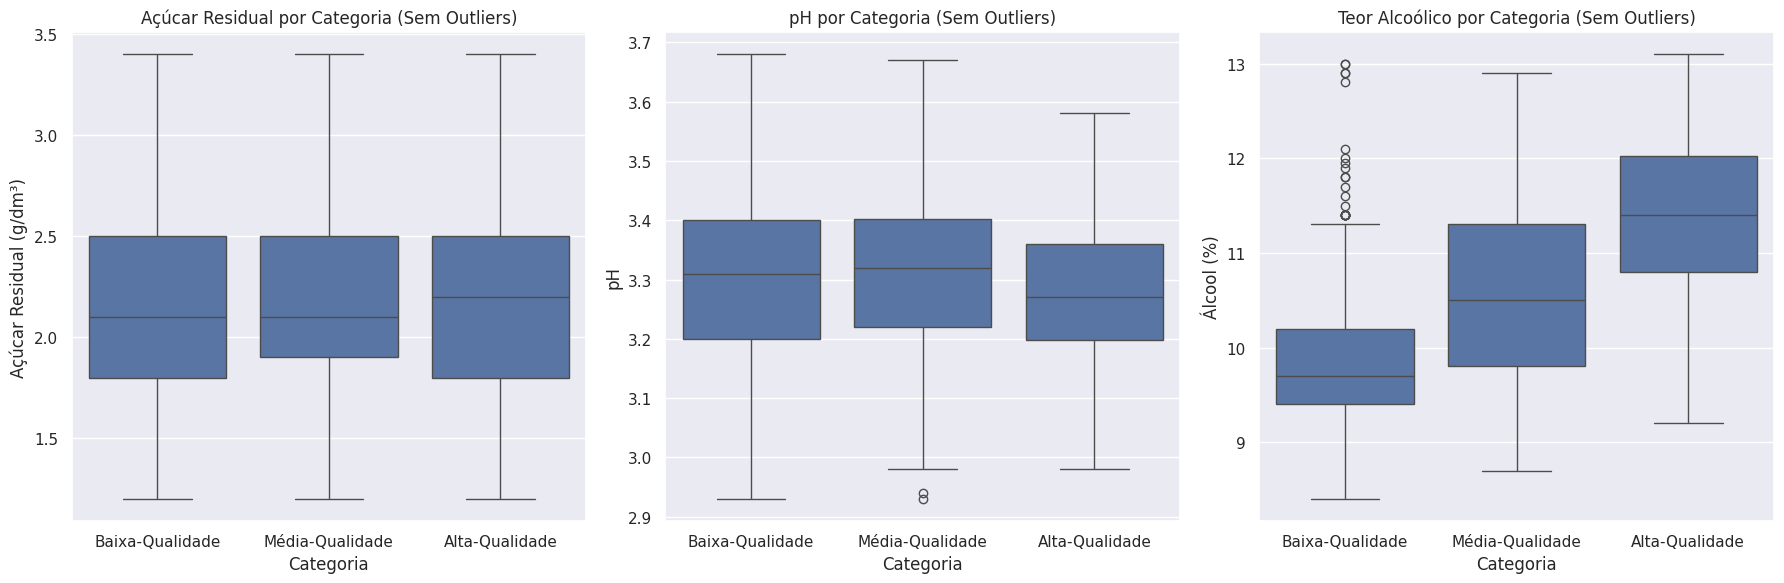

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(data=df_sem_outliers_final, x='Categoria', y='residual sugar', ax=ax[0])
ax[0].set_title("Açúcar Residual por Categoria (Sem Outliers)")
ax[0].set_ylabel("Açúcar Residual (g/dm³)")

sns.boxplot(data=df_sem_outliers_final, x='Categoria', y='pH', ax=ax[1])
ax[1].set_title("pH por Categoria (Sem Outliers)")
ax[1].set_ylabel("pH")

sns.boxplot(data=df_sem_outliers_final, x='Categoria', y='alcohol', ax=ax[2])
ax[2].set_title("Teor Alcoólico por Categoria (Sem Outliers)")
ax[2].set_ylabel("Álcool (%)")
plt.tight_layout()
plt.show()